<a href="https://colab.research.google.com/github/phuonglinhday1048-hue/Phantichdl-hs/blob/main/Lab10_DangNgocPhuongLinh_2474802010559.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
#PHẦN 1: TIỀN XỬ LÝ VÀ TRỰC QUAN HÓA DỮ LIỆU
#Câu 1: Nạp và Khám phá dữ liệu
df = sns.load_dataset("titanic")

print("===== 5 dòng đầu tiên =====")
print(df.head())

print("\n===== Thông tin tổng quan =====")
print(df.info())


===== 5 dòng đầu tiên =====
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

===== Thông tin tổng quan =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  -----

In [3]:
# Câu 2: Xử lý giá trị khuyết
print("\n===== Số lượng giá trị khuyết của từng cột =====")
print(df.isnull().sum())

# Xóa cột deck
df = df.drop(columns=['deck'])

print("\nCác cột sau khi xóa deck:")
print(df.columns)

# Điền giá trị khuyết của age bằng trung bình
mean_age = df['age'].mean()
df['age'] = df['age'].fillna(mean_age)

print("\nKiểm tra số giá trị khuyết của age sau khi điền:")
print(df['age'].isnull().sum())



===== Số lượng giá trị khuyết của từng cột =====
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Các cột sau khi xóa deck:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

Kiểm tra số giá trị khuyết của age sau khi điền:
0


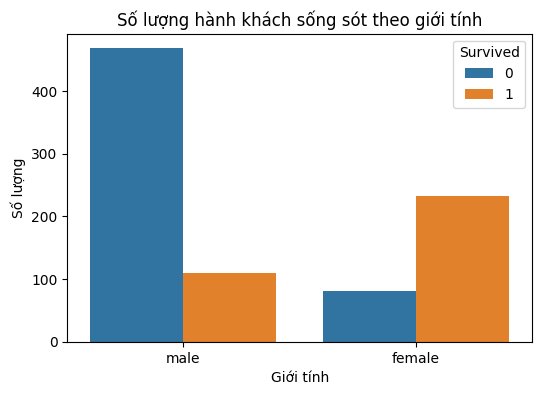

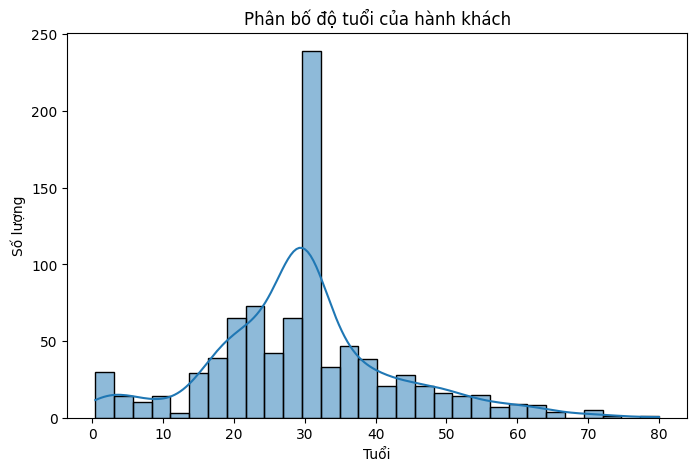

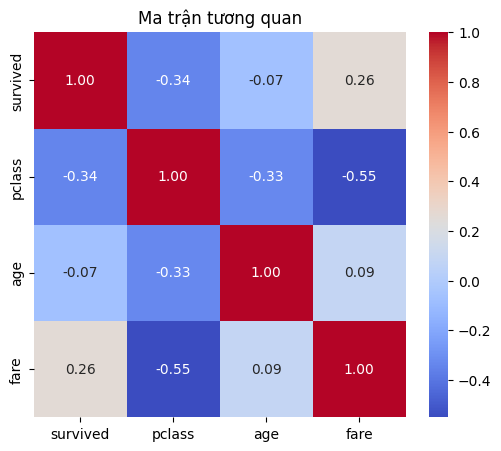

In [4]:
# Câu 3: Phân tích và trực quan hóa
# 1. Biểu đồ số lượng sống sót theo giới tính
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', hue='survived')
plt.title("Số lượng hành khách sống sót theo giới tính")
plt.xlabel("Giới tính")
plt.ylabel("Số lượng")
plt.legend(title="Survived")
plt.show()
# 2. Biểu đồ phân bố tuổi
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Phân bố độ tuổi của hành khách")
plt.xlabel("Tuổi")
plt.ylabel("Số lượng")
plt.show()
# 3. Ma trận tương quan và Heatmap
corr = df[['survived','pclass','age','fare']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Ma trận tương quan")
plt.show()


In [5]:
# Câu 4: Mã hóa dữ liệu
# 1. Label Encoding (map)
df['sex'] = df['sex'].map({
    'male':0,
    'female':1
})

print("\n===== Cột sex sau khi mã hóa =====")
print(df[['sex']].head())


# 2. One-Hot Encoding cho embarked
embarked_dummy = pd.get_dummies(df['embarked'],
                                prefix='embarked')

# Ghép vào DataFrame
df = pd.concat([df, embarked_dummy], axis=1)

print("\n===== DataFrame sau khi One-Hot Encoding =====")
print(df.head())

print("\n===== Danh sách các cột =====")
print(df.columns)


===== Cột sex sau khi mã hóa =====
   sex
0    0
1    1
2    1
3    1
4    0

===== DataFrame sau khi One-Hot Encoding =====
   survived  pclass  sex   age  sibsp  parch     fare embarked  class    who  \
0         0       3    0  22.0      1      0   7.2500        S  Third    man   
1         1       1    1  38.0      1      0  71.2833        C  First  woman   
2         1       3    1  26.0      0      0   7.9250        S  Third  woman   
3         1       1    1  35.0      1      0  53.1000        S  First  woman   
4         0       3    0  35.0      0      0   8.0500        S  Third    man   

   adult_male  embark_town alive  alone  embarked_C  embarked_Q  embarked_S  
0        True  Southampton    no  False       False       False        True  
1       False    Cherbourg   yes  False        True       False       False  
2       False  Southampton   yes   True       False       False        True  
3       False  Southampton   yes  False       False       False        True  
4  

In [6]:
#PHẦN 2: XÂY DỰNG MÔ HÌNH HỌC SÂU CƠ BẢN
#Câu 5: Chuẩn bị dữ liệu cho Học sâu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Tạo X và y
X = df[['pclass', 'sex', 'age']]
y = df['survived']

print("X:")
print(X.head())

print("\ny:")
print(y.head())

# Chia dữ liệu Train/Test (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nKích thước dữ liệu:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nChuẩn hóa dữ liệu hoàn tất!")

X:
   pclass  sex   age
0       3    0  22.0
1       1    1  38.0
2       3    1  26.0
3       1    1  35.0
4       3    0  35.0

y:
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

Kích thước dữ liệu:
X_train: (712, 3)
X_test : (179, 3)
y_train: (712,)
y_test : (179,)

Chuẩn hóa dữ liệu hoàn tất!


In [7]:
pip install tensorflow

In [9]:
#Câu 6: Xây dựng mạng Nơ-ron nhân tạo (ANN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Khởi tạo mô hình
model = Sequential()

# Lớp ẩn
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(3,)
))

# Lớp đầu ra
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Compile mô hình
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Xem kiến trúc mô hình
model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("KẾT QUẢ ĐÁNH GIÁ")
print("Loss     :", round(loss, 4))
print("Accuracy :", round(accuracy * 100, 2), "%")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7065 - loss: 0.6100 - val_accuracy: 0.7273 - val_loss: 0.5935
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7364 - loss: 0.5814 - val_accuracy: 0.7273 - val_loss: 0.5608
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7645 - loss: 0.5582 - val_accuracy: 0.7552 - val_loss: 0.5370
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7715 - loss: 0.5418 - val_accuracy: 0.7622 - val_loss: 0.5168
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7786 - loss: 0.5290 - val_accuracy: 0.7692 - val_loss: 0.5011
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7838 - loss: 0.5190 - val_accuracy: 0.7692 - val_loss: 0.4887
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7803 - loss: 0.5108 - val_accuracy: 0.7622 - val_loss: 0.4779
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7856 - loss: 0.5040 - val_accuracy: 0.7622 - val_loss